# Demostración Propuesta 3: Doble Convolución Cuántica

**Objetivo:**
1. Cargar Dataset Balanceado (agrupado por pacientes para evitar data leakage).
2. Pre-procesar imágenes con **Doble Capa Cuántica Variacional (Downsampling)**.
   - Entrada: 128x128
   - Circuito: 2 Qubits, Amplitude Encoding
   - Salida: 32x32 (Feature Map tras 2 capas de convolución)
3. Entrenar Red Neuronal Clásica (MLP) con los mapas de características cuánticos de 32x32.
4. Validación: Leave-One-Out Cross-Validation (LOOCV) por paciente.



In [8]:
import os
import glob
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import sys

# Importar utilidades cuánticas locales
from quantum_utils import QuantumDownsampler

print(f"Torch Version: {torch.__version__}")

Torch Version: 2.9.1


In [9]:
# --- CONFIGURACIÓN ---
PATH_BALANCED = '../Dataset_Balanceado_700' # Ruta relativa desde Codigo/Propuesta2/
LABEL_MAP = {1: 0, 2: 1, 3: 2} # Meningioma, Glioma, Pituitary
CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']

# Determinar dispositivo para la Red Neuronal (Clásica)
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
    
print(f"Dispositivo para NN: {DEVICE}")

Dispositivo para NN: mps


In [10]:
# --- CLASES DEL MODELO ---

class RedNeuronalGeneral(nn.Module):
    """
    MLP Clásico definido en loocv_redNeuronal.ipynb
    Input: (Batch, 1, 32, 32) -> Flatten -> 1024
    """
    def __init__(self, input_shape, num_classes=3):
        super(RedNeuronalGeneral, self).__init__()
        self.input_dim = np.prod(input_shape)
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(self.input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.3), 
            nn.Linear(256, 128), 
            nn.BatchNorm1d(128), 
            nn.LeakyReLU(0.1), 
            nn.Dropout(0.2), 
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers(x)
        return logits

class QuantumFeatureDataset(Dataset):
    """
    Dataset simple para manejar los features cuánticos ya procesados.
    Evita conversiones innecesarias a PIL para mantener precisión float.
    """
    def __init__(self, features_list, labels_list):
        # Convertir lista de arrays a un solo tensor grande
        # features_list: [ (32,32), (32,32), ... ]
        # Resultado: (N, 1, 32, 32)
        self.features = torch.tensor(np.array(features_list), dtype=torch.float32).unsqueeze(1)
        self.labels = torch.tensor(labels_list, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

In [11]:
# --- FUNCIÓN DE CARGA Y PRE-PROCESAMIENTO CUÁNTICO ---

def load_and_process_data(root_path):
    """
    Carga imágenes, las pasa por el circuito cuántico y retorna un diccionario organizado por paciente.
    """
    print(f"--- Iniciando carga y procesamiento cuántico desde: {root_path} ---")
    
    # Inicializar el Downsampler una sola vez (Propuesta 3 aplica 2 capas por defecto)
    q_sampler = QuantumDownsampler(n_qubits=2)
    print("Circuito Cuántico Inicializado.")
    
    folder_map = {
        'Meningioma': 1,
        'Glioma': 2,
        'Adenoma_hipofisario': 3
    }

    data_by_patient = defaultdict(lambda: {'features': [], 'labels': []})
    total_processed = 0
    start_total = time.time()

    for folder, label_orig in folder_map.items():
        path = os.path.join(root_path, folder)
        files = glob.glob(os.path.join(path, '*.npz'))
        label_idx = LABEL_MAP[label_orig]
        
        print(f"Procesando {folder} ({len(files)} pacientes)...")
        
        for f_path in files:
            try:
                # Identificar Paciente
                filename = os.path.basename(f_path)
                patient_id = filename.replace('patient_', '').replace('paciente_', '').replace('.npz', '')
                
                # Cargar NPZ
                data = np.load(f_path)
                imgs = data['imagenes'] if 'imagenes' in data else data['images']
                
                # Determinar etiqueta
                if 'etiqueta' in data:
                    lbl = data['etiqueta']
                    lbl_idx = LABEL_MAP[int(lbl)] if lbl > 0 else label_idx
                else:
                    lbl_idx = label_idx
                
                # Procesar cada imagen del paciente
                for i in range(imgs.shape[0]):
                    img_raw = imgs[i]
                    
                    # PROCESAMIENTO CUÁNTICO
                    # process_image aplica 2 capas para obtener 32x32
                    q_feature_map = q_sampler.process_image(img_raw, n_layers=2)
                    
                    data_by_patient[patient_id]['features'].append(q_feature_map)
                    data_by_patient[patient_id]['labels'].append(lbl_idx)
                    
                    total_processed += 1
                    
                    if total_processed % 100 == 0:
                        print(f"  -> {total_processed} imágenes procesadas...", end='')
                        
            except Exception as e:
                print(f"Error en {filename}: {e}")

    elapsed = time.time() - start_total
    print(f"Procesamiento Completado. {total_processed} imágenes en {elapsed:.2f}s.")
    print(f"Promedio: {elapsed/total_processed:.4f} s/imagen")
    return data_by_patient

In [12]:
# --- FUNCIÓN DE VALIDACIÓN CRUZADA LOSOCV ---
def run_loocv_propuesta3(data_by_patient, device, epochs=10):
    patient_ids = list(data_by_patient.keys())
    
    global_true = []
    global_pred = []
    
    num_patients = len(patient_ids)
    print(f"Iniciando Validación Cruzada (LOSOCV) con {num_patients} pacientes...")
    
    for i, test_pid in enumerate(patient_ids):
        # 1. Split Train/Test
        test_feats = data_by_patient[test_pid]['features']
        test_lbls = data_by_patient[test_pid]['labels']
        
        if not test_feats: continue

        train_feats = []
        train_lbls = []
        for pid in patient_ids:
            if pid != test_pid:
                train_feats.extend(data_by_patient[pid]['features'])
                train_lbls.extend(data_by_patient[pid]['labels'])
        
        # 2. DataLoaders
        train_ds = QuantumFeatureDataset(train_feats, train_lbls)
        test_ds = QuantumFeatureDataset(test_feats, test_lbls)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
        
        # 3. Modelo y Entrenamiento
        model = RedNeuronalGeneral(input_shape=(1, 32, 32), num_classes=3).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        model.train()
        for epoch in range(epochs):
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        # 4. Evaluación
        model.eval()
        p_true = []
        p_pred = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                p_true.extend(labels.cpu().numpy())
                p_pred.extend(predicted.cpu().numpy())
        
        global_true.extend(p_true)
        global_pred.extend(p_pred)
        
        # Progreso
        if (i+1) % 10 == 0 or (i+1) == num_patients:
            acc = np.mean(np.array(p_true) == np.array(p_pred)) if p_true else 0
            print(f"[{i+1}/{num_patients}] Paciente {test_pid} - Acc: {acc:.2f}")

    return global_true, global_pred


--- Iniciando carga y procesamiento cuántico desde: ../Dataset_Balanceado_700 ---
Circuito Cuántico Inicializado.
Procesando Meningioma (82 pacientes)...
  -> 100 imágenes procesadas...  -> 200 imágenes procesadas...  -> 300 imágenes procesadas...  -> 400 imágenes procesadas...  -> 500 imágenes procesadas...  -> 600 imágenes procesadas...  -> 700 imágenes procesadas...Procesando Glioma (89 pacientes)...
  -> 800 imágenes procesadas...  -> 900 imágenes procesadas...  -> 1000 imágenes procesadas...  -> 1100 imágenes procesadas...  -> 1200 imágenes procesadas...  -> 1300 imágenes procesadas...Procesando Adenoma_hipofisario (62 pacientes)...
  -> 1400 imágenes procesadas...  -> 1500 imágenes procesadas...  -> 1600 imágenes procesadas...  -> 1700 imágenes procesadas...  -> 1800 imágenes procesadas...  -> 1900 imágenes procesadas...  -> 2000 imágenes procesadas...Procesamiento Completado. 2098 imágenes en 9.93s.
Promedio: 0.0047 s/imagen
Iniciando Validación Cruzada (LOSOCV) con 233 paciente

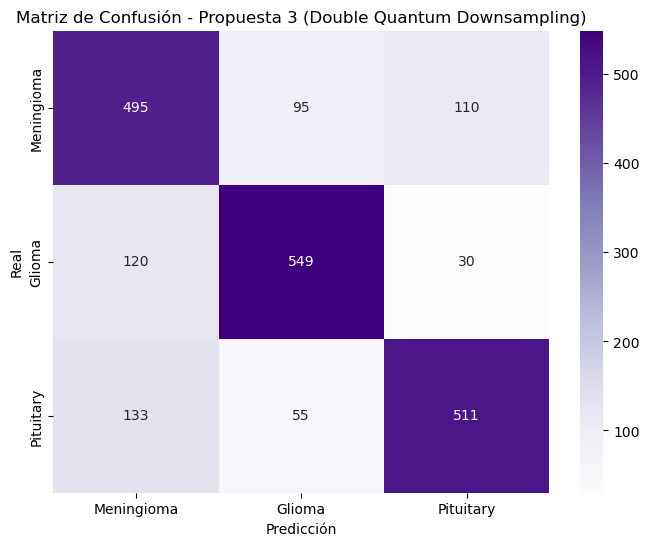

In [13]:

# --- MAIN ---

if __name__ == "__main__":
    if os.path.exists(PATH_BALANCED):
        # 1. Cargar y Procesar (Esto tardará un poco, pero se hace una sola vez)
        data_processed = load_and_process_data(PATH_BALANCED)
        
        # 2. Ejecutar LOOCV
        y_true, y_pred = run_loocv_propuesta3(data_processed, DEVICE, epochs=10)
        
        # 3. Reporte
        print("\n--- RESULTADOS FINALES PROPUESTA 3 ---")
        print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
        
        # Matriz de Confusión
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        try:
            import seaborn as sns
            sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        except ImportError:
            plt.imshow(cm, cmap='Purples')
            plt.colorbar()
        
        plt.xlabel('Predicción')
        plt.ylabel('Real')
        plt.title('Matriz de Confusión - Propuesta 3 (Double Quantum Downsampling)')
        plt.show()
        
    else:
        print(f"ERROR: No se encuentra el dataset en {PATH_BALANCED}")